In [1]:
%pip install -q imbalanced-learn

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import chi2
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Change the file name here if your CSV is saved under a different name
candidates = ["/content/Fraud Detection Dataset (3).csv"]
DATA_PATH = next((p for p in candidates if os.path.exists(p)), candidates[0])
df = pd.read_csv(DATA_PATH)
print(df.shape)

(51000, 12)


In [5]:
print(list(df.columns))

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


# Partition

In [7]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
len(partition)

35700

# Random

In [8]:
sample_random = df.sample(n=100, random_state=42)
sample_random.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


# Stratified

In [9]:
sample_stratified = df.groupby("Location", group_keys=False).sample(frac=0.1, random_state=42)
print(sample_stratified["Location"].value_counts())
sample_stratified.head()

Location
Boston           615
New York         611
Seattle          610
Chicago          607
Houston          603
Los Angeles      601
Miami            599
San Francisco    598
Name: count, dtype: int64


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
23597,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
50817,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
43719,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
40025,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
41638,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


In [10]:
# Stratified sample of exactly 500 rows (rows with a missing Location are excluded)
df_loc = df.dropna(subset=["Location"])
sample_500, _ = train_test_split(df_loc, train_size=500, stratify=df_loc["Location"], random_state=42)
print(len(sample_500))
print(sample_500["Location"].value_counts())

500
Location
Chicago          63
New York         63
Boston           63
Seattle          63
Los Angeles      62
Miami            62
Houston          62
San Francisco    62
Name: count, dtype: int64


In [11]:
# The dataset has Location (city) instead of Country
print(df["Location"].dropna().unique().tolist())
location_counts = df["Location"].value_counts(dropna=False)
print(location_counts)

['San Francisco', 'New York', 'Chicago', 'Boston', 'Houston', 'Miami', 'Los Angeles', 'Seattle']
Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
NaN              2547
Name: count, dtype: int64


In [12]:
min_count = df["Location"].value_counts().min()
sample_equal = df.groupby("Location", group_keys=False).sample(n=min_count, random_state=42)
print(sample_equal["Location"].value_counts())

Location
Boston           5985
Chicago          5985
Houston          5985
Los Angeles      5985
Miami            5985
New York         5985
San Francisco    5985
Seattle          5985
Name: count, dtype: int64


# Cluster

In [13]:
locations = df["Location"].dropna().unique()
selected_locations = pd.Series(locations).sample(n=2, random_state=42)
sample_cluster = df[df["Location"].isin(selected_locations)]
print(selected_locations.tolist())
sample_cluster.head()

['New York', 'Miami']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0


In [14]:
counts = df["Location"].value_counts()
top5 = counts.head(5).index.tolist()
bottom5 = counts.tail(5).index.tolist()
print("5 most listed :", top5)
print("5 least listed:", bottom5)
print("In both lists :", sorted(set(top5) & set(bottom5)), "(only 8 locations exist)")

sample_top5 = df[df["Location"].isin(top5)].sample(n=100, random_state=42)
sample_bottom5 = df[df["Location"].isin(bottom5)].sample(n=100, random_state=42)
print(sample_top5["Location"].value_counts())
print(sample_bottom5["Location"].value_counts())

5 most listed : ['Boston', 'New York', 'Seattle', 'Chicago', 'Houston']
5 least listed: ['Chicago', 'Houston', 'Los Angeles', 'Miami', 'San Francisco']
In both lists : ['Chicago', 'Houston'] (only 8 locations exist)
Location
Seattle     23
Chicago     22
Boston      22
Houston     18
New York    15
Name: count, dtype: int64
Location
San Francisco    25
Chicago          25
Los Angeles      22
Miami            21
Houston           7
Name: count, dtype: int64


# Data Selection

## 1. Missing Values

In [15]:
missing = pd.DataFrame({"missing": df.isna().sum(), "percent": (df.isna().mean() * 100).round(2)})
print(missing[missing["missing"] > 0])

                     missing  percent
Transaction_Amount      2520     4.94
Time_of_Transaction     2552     5.00
Device_Used             2473     4.85
Location                2547     4.99
Payment_Method          2469     4.84


## 2. Identical Values

In [16]:
print("Exact duplicate rows      :", df.duplicated().sum())
print("Duplicate Transaction_IDs :", df["Transaction_ID"].duplicated().sum())
print("Unique values per column:")
print(df.nunique())
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print("Constant columns:", constant_cols)

# Each Transaction_ID should appear once, so repeated IDs are removed (first row kept)
df_clean = df.drop_duplicates(subset="Transaction_ID", keep="first").reset_index(drop=True)
print("Rows before / after:", len(df), "/", len(df_clean))

Exact duplicate rows      : 881
Duplicate Transaction_IDs : 1000
Unique values per column:
Transaction_ID                      50000
User_ID                              4000
Transaction_Amount                  44821
Transaction_Type                        5
Time_of_Transaction                    24
Device_Used                             4
Location                                8
Previous_Fraudulent_Transactions        5
Account_Age                           119
Number_of_Transactions_Last_24H        14
Payment_Method                          5
Fraudulent                              2
dtype: int64
Constant columns: []
Rows before / after: 51000 / 50000


## 3. Correlation Analysis

Number_of_Transactions_Last_24H    -0.003891
Previous_Fraudulent_Transactions    0.000634
Transaction_Amount                  0.004995
Account_Age                         0.005704
Time_of_Transaction                 0.005998
User_ID                             0.007373
Fraudulent                          1.000000
Name: Fraudulent, dtype: float64


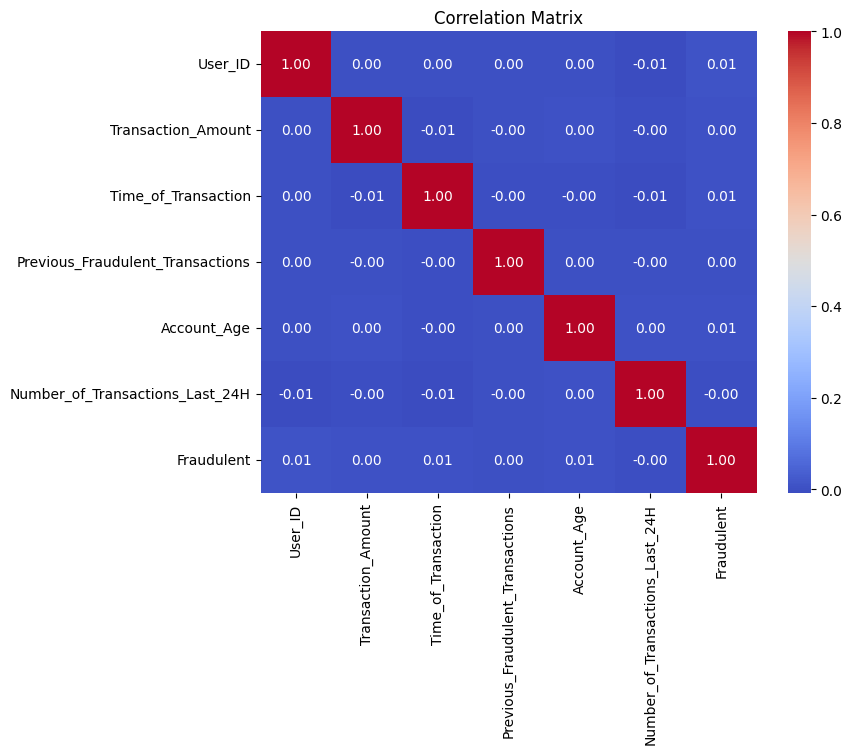

In [17]:
corr = df_clean.corr(numeric_only=True)
print(corr["Fraudulent"].sort_values())

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 4. Chi-Square Test
Missing numbers are filled with the median and scaled to 0-1, missing text values become a "Missing" category, and text columns are one-hot encoded, because chi-square needs non-negative numbers. `Transaction_ID` and `User_ID` are identifiers and are left out.

In [18]:
X = df_clean.drop(columns=["Transaction_ID", "User_ID", "Fraudulent"])
Y = df_clean["Fraudulent"]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scale", MinMaxScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

Xt = preprocess.fit_transform(X)
scores, pvalues = chi2(Xt, Y)
chi_result = pd.DataFrame({
    "Feature": preprocess.get_feature_names_out(),
    "Chi2 Score": scores,
    "p-value": pvalues,
}).sort_values("Chi2 Score", ascending=False)
print(chi_result.to_string(index=False))
print("Features with p-value < 0.05:", int((chi_result["p-value"] < 0.05).sum()), "of", len(chi_result))

                              Feature  Chi2 Score  p-value
             cat__Device_Used_Missing    7.541055 0.006031
                cat__Location_Chicago    4.750992 0.029281
                cat__Location_Seattle    4.299105 0.038132
          cat__Payment_Method_Missing    2.305596 0.128909
              cat__Device_Used_Tablet    2.218758 0.136343
              cat__Device_Used_Mobile    2.017179 0.155528
 cat__Transaction_Type_ATM Withdrawal    1.229673 0.267471
                cat__Location_Houston    0.943962 0.331261
cat__Transaction_Type_Online Purchase    0.913925 0.339075
              cat__Payment_Method_UPI    0.881682 0.347741
             cat__Device_Used_Desktop    0.837899 0.359998
            cat__Location_Los Angeles    0.707304 0.400340
               cat__Location_New York    0.401848 0.526136
             num__Time_of_Transaction    0.298404 0.584884
                     num__Account_Age    0.276370 0.599091
  cat__Transaction_Type_Bank Transfer    0.194204 0.6594

# Split

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
print(X_train.shape, X_test.shape)
print("Fraud share in train / test:", round(Y_train.mean(), 4), "/", round(Y_test.mean(), 4))

(35000, 9) (15000, 9)
Fraud share in train / test: 0.0492 / 0.0492


# Task 5: ML Model

## Model: Random Forest
Pipeline: imputing, scaling and encoding, then SMOTE to balance the fraud class (applied to training data only), then Random Forest.

In [20]:
model = ImbPipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                   random_state=42, n_jobs=-1)),
])

In [21]:
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [accuracy_score(Y_test, Y_pred),
              precision_score(Y_test, Y_pred, zero_division=0),
              recall_score(Y_test, Y_pred),
              f1_score(Y_test, Y_pred),
              roc_auc_score(Y_test, Y_prob)],
}).round(4)
print(results.to_string(index=False))
print("Accuracy of always predicting 'not fraud':", round(1 - Y_test.mean(), 4))
print()
print(classification_report(Y_test, Y_pred, target_names=["Not fraud", "Fraud"], zero_division=0))

   Metric  Value
 Accuracy 0.7330
Precision 0.0550
   Recall 0.2737
 F1-score 0.0916
  ROC-AUC 0.5108
Accuracy of always predicting 'not fraud': 0.9508

              precision    recall  f1-score   support

   Not fraud       0.95      0.76      0.84     14262
       Fraud       0.06      0.27      0.09       738

    accuracy                           0.73     15000
   macro avg       0.50      0.52      0.47     15000
weighted avg       0.91      0.73      0.81     15000



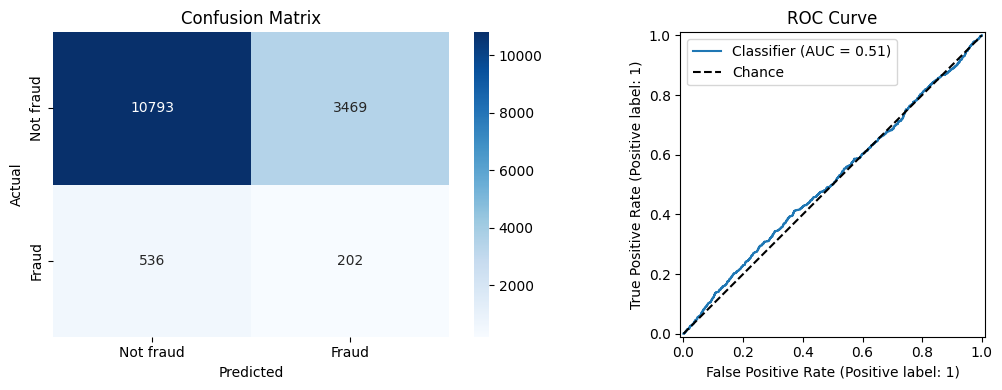

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Not fraud", "Fraud"], yticklabels=["Not fraud", "Fraud"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual"); ax[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(Y_test, Y_prob, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", label="Chance")
ax[1].legend(); ax[1].set_title("ROC Curve")
plt.tight_layout(); plt.show()

In [23]:
cv_auc = cross_val_score(model, X_train, Y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring="roc_auc")
print("5-fold ROC-AUC on training data:", cv_auc.round(4), "| mean:", round(cv_auc.mean(), 4))

5-fold ROC-AUC on training data: [0.4928 0.488  0.5251 0.4675 0.5114] | mean: 0.4969


In [24]:
names = model.named_steps["prep"].get_feature_names_out()
importance = pd.Series(model.named_steps["clf"].feature_importances_, index=names)
print("Top 10 feature importances:")
print(importance.sort_values(ascending=False).head(10).round(4))

Top 10 feature importances:
num__Previous_Fraudulent_Transactions    0.2898
num__Number_of_Transactions_Last_24H     0.1641
num__Time_of_Transaction                 0.1127
num__Transaction_Amount                  0.0746
num__Account_Age                         0.0536
cat__Location_Seattle                    0.0300
cat__Payment_Method_Missing              0.0257
cat__Location_Missing                    0.0215
cat__Location_Chicago                    0.0196
cat__Location_San Francisco              0.0186
dtype: float64


# Result Analysis

**Data.** The file has 51,000 rows. Removing 1,000 repeated Transaction_IDs leaves 50,000 transactions. Fraud makes up 4.92% of both the training and the test set.

**Feature selection.** Correlations with `Fraudulent` are all between -0.004 and 0.007. In the chi-square test only 3 of 30 encoded features have p < 0.05 (`Device_Used` missing, `Location` Chicago, `Location` Seattle). With 30 tests, one or two p-values below 0.05 are expected by chance alone.

**Model: Random Forest (SMOTE on training data only)**

| Metric | Test set |
|---|---|
| Accuracy | 0.7330 |
| Precision | 0.0550 |
| Recall | 0.2737 |
| F1-score | 0.0916 |
| ROC-AUC | 0.5108 |

- ROC-AUC is 0.5108 on the test set and 0.4969 on average in 5-fold cross-validation. A value of 0.5 is the same as random guessing.
- Accuracy (0.7330) is below the 0.9508 obtained by always predicting "not fraud". The model catches 27% of frauds, but only 5.5% of its fraud flags are correct. That precision is close to the fraud share in the data (4.9%).
- `Previous_Fraudulent_Transactions` (0.29) and `Number_of_Transactions_Last_24H` (0.16) have the highest importance. With an ROC-AUC near 0.5 these importances reflect fitting noise and should not be read as fraud drivers.

**Conclusion.** The model does not separate fraud from non-fraud better than chance on this data, so it is not usable for fraud detection. Precision, recall and ROC-AUC are reported instead of accuracy because the classes are imbalanced.